In [24]:
#imports & setup
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

sns.set(style = "whitegrid")
os.makedirs("images", exist_ok = True)

In [4]:
#paths
DATA_PATH = "outputs/df_preprocessed.csv"   
MODEL_PATH = "artifacts/churn_model.joblib"
META_PATH  = "artifacts/metadata.json"
RANDOM_STATE = 42

In [6]:
# Load data & artifacts, rebuild split exactly as in modeling

#load data & trained pipeline
df = pd.read_csv(DATA_PATH)

pipe = joblib.load(MODEL_PATH)
with open(META_PATH, "r", encoding = "utf-8") as f:
    meta = json.load(f)

model_name = meta.get("model_name", "unknown")
num_cols   = meta.get("num_cols", ["tenure", "MonthlyCharges", "TotalCharges"])
cat_cols   = meta.get("cat_cols", [])
saved_thr  = meta.get("threshold", None)

print("Model:", model_name)
print("Saved threshold:", saved_thr)
print("Numeric cols:", num_cols)
print("Categorical cols (first 5):", cat_cols[:5])

#rebuild the same split used in modeling (stratified, 80/20, random_state = 42)
X = df.drop(columns = ["Churn", "customerID"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size = 0.2, random_state = RANDOM_STATE
)

X_test.shape, y_test.mean().round(3)

Model: unknown
Saved threshold: None
Numeric cols: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical cols (first 5): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService']


((1409, 19), 0.265)

In [7]:
# Recover feature names from the fitted preprocessor

#grab feature names from the fitted ColumnTransformer inside the pipeline
pre = pipe.named_steps["pre"]
ohe = pre.named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
feat_names = num_cols + cat_names

len(feat_names), feat_names[:10]

(46,
 ['tenure',
  'MonthlyCharges',
  'TotalCharges',
  'gender_Female',
  'gender_Male',
  'SeniorCitizen_0',
  'SeniorCitizen_1',
  'Partner_No',
  'Partner_Yes',
  'Dependents_No'])

In [9]:
# Confusion matrix at the saved threshold

proba = pipe.predict_proba(X_test)[:, 1]

def metrics_at_threshold(y_true, y_score, t):
    pred = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    prec = tp/(tp + fp + 1e-9); rec = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    return prec, rec, f1, (tn, fp, fn, tp)

thr = saved_thr if saved_thr is not None else 0.5
prec, rec, f1, (tn, fp, fn, tp) = metrics_at_threshold(y_test, proba, thr)
print(f"Operating threshold: {thr:.2f} | Precision = {prec:.3f} Recall = {rec:.3f} F1 = {f1:.3f}")
print("Confusion matrix [tn, fp; fn, tp]:", [[tn, fp],[fn, tp]])

Operating threshold: 0.50 | Precision = 0.504 Recall = 0.783 F1 = 0.614
Confusion matrix [tn, fp; fn, tp]: [[747, 288], [81, 293]]


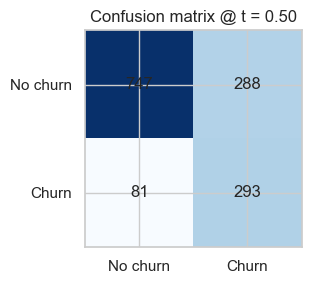

Test ROC-AUC: 0.842
Test PR-AUC: 0.633


In [10]:
#plot confusion matrix
plt.figure(figsize = (4, 3))
cm = np.array([[tn, fp], [fn, tp]])
plt.imshow(cm, cmap = "Blues")
for (i,j),v in np.ndenumerate(cm):
    plt.text(j, i, f"{v}", ha = "center", va = "center", fontsize = 12)
plt.xticks([0, 1], ["No churn", "Churn"]); plt.yticks([0, 1], ["No churn", "Churn"])
plt.title(f"Confusion matrix @ t = {thr:.2f}")
plt.tight_layout(); plt.savefig("images/confusion_matrix.png", dpi = 300); plt.show()

print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("Test PR-AUC:", round(average_precision_score(y_test, proba), 3))

C:\Users\пк\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


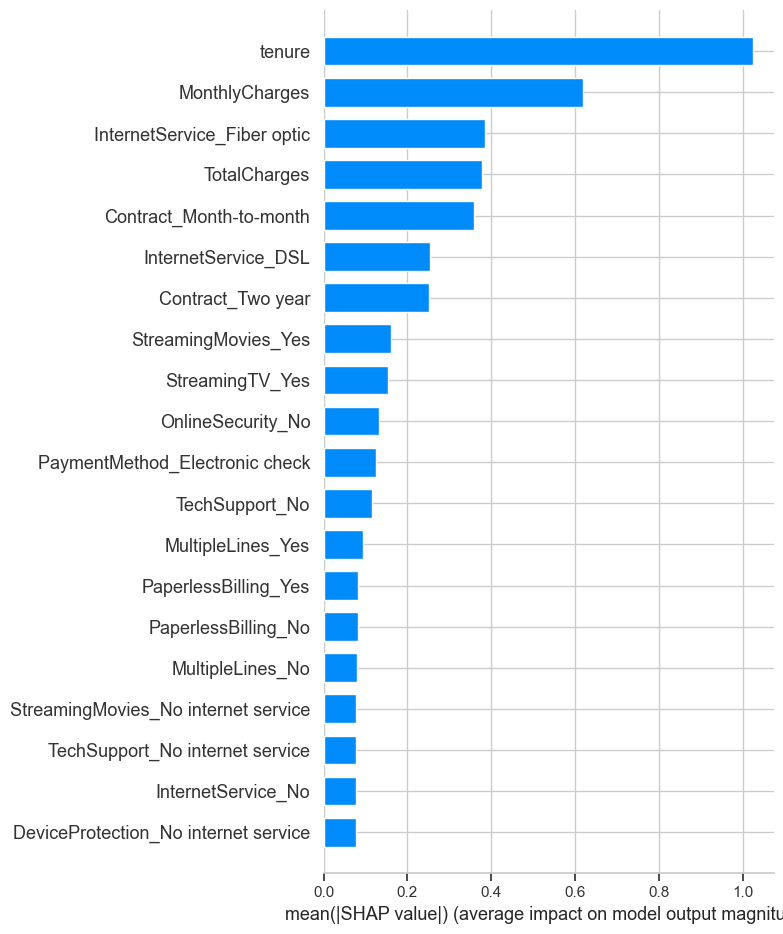

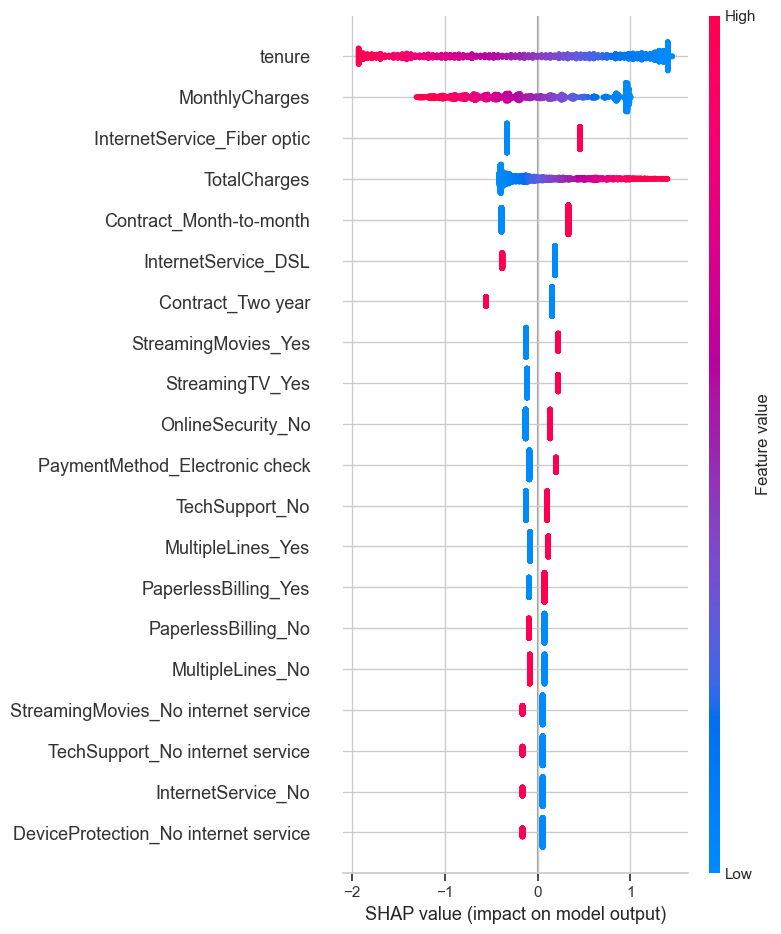

In [13]:
# SHAP — global explanations (summary bar + beeswarm)

#determine explainer type (tree vs linear)
clf = pipe.named_steps["clf"]
Xte_trans = pre.transform(X_test)

is_tree = hasattr(clf, "estimators_") or clf.__class__.__name__.lower().startswith(("randomforest", "xgboost", "lightgbm"))

if is_tree:
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(Xte_trans)
    sv_for_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    explainer = shap.LinearExplainer(clf, Xte_trans, feature_perturbation = "interventional")
    sv_for_plot = explainer.shap_values(Xte_trans)

#summary bar (global importance)
shap.summary_plot(sv_for_plot, Xte_trans, feature_names = feat_names, plot_type = "bar", show = False)
plt.tight_layout(); plt.savefig("images/shap_summary_bar.png", dpi = 300, bbox_inches = "tight"); plt.show()

#beeswarm (directional effect)
shap.summary_plot(sv_for_plot, Xte_trans, feature_names = feat_names, show = False)
plt.tight_layout(); plt.savefig("images/shap_summary_beeswarm.png", dpi = 300, bbox_inches = "tight"); plt.show()

In [14]:
# SHAP — dependence plots for top features

#rank features by mean |SHAP| (global impact)
mean_abs = np.abs(sv_for_plot).mean(axis = 0)
top_idx = np.argsort(-mean_abs)[:5]
top_feats = [feat_names[i] for i in top_idx]
top_feats

['tenure',
 'MonthlyCharges',
 'InternetService_Fiber optic',
 'TotalCharges',
 'Contract_Month-to-month']

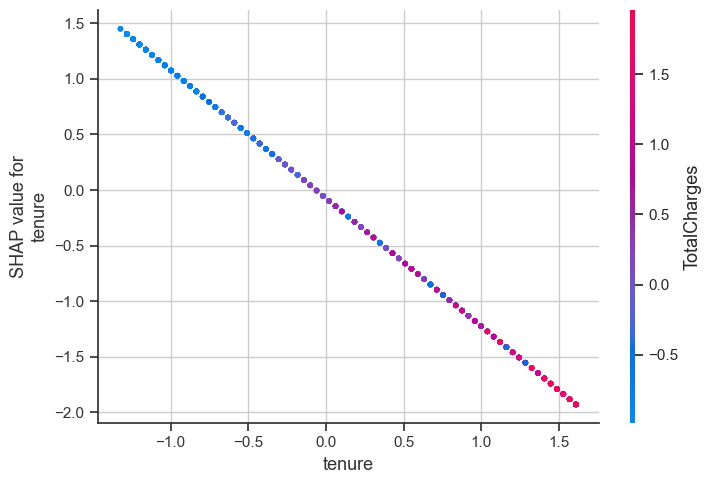

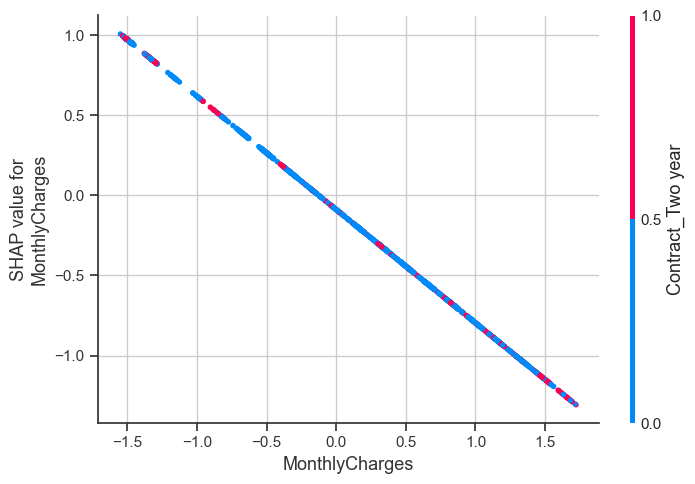

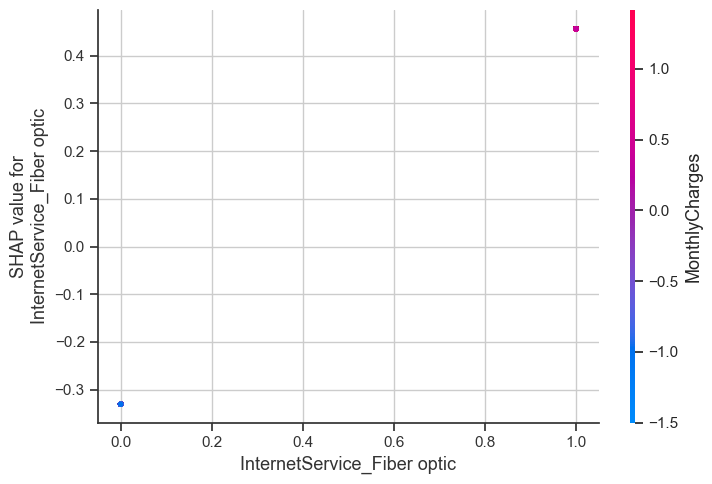

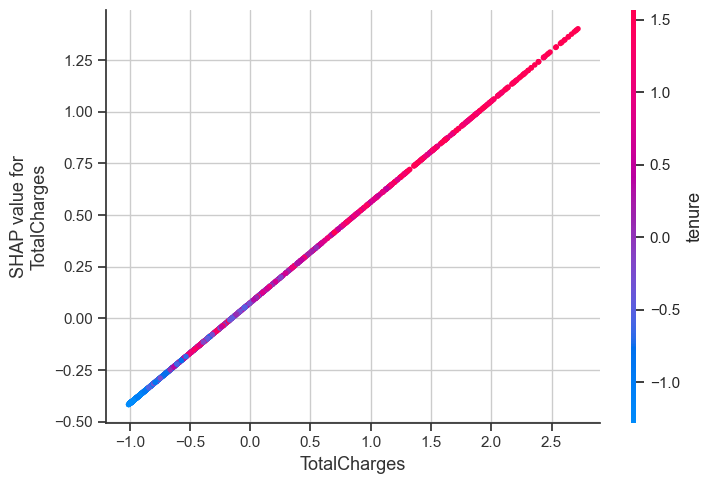

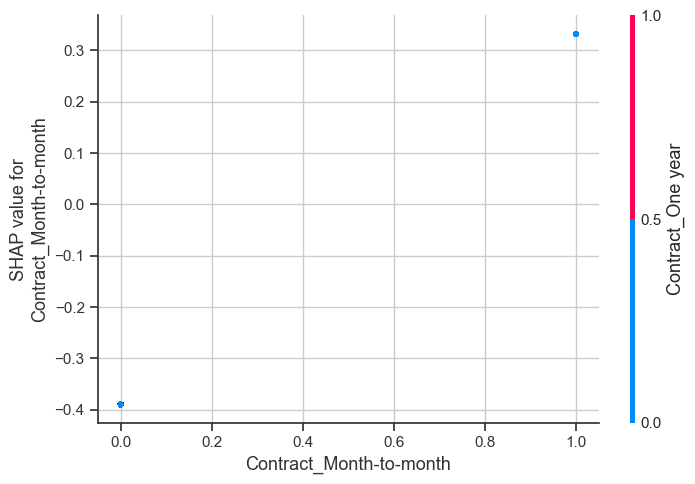

In [15]:
#dependence plots for the top drivers
for f in top_feats:
    shap.dependence_plot(f, sv_for_plot, Xte_trans, feature_names = feat_names, show = False)
    safe = f.replace("/", "_").replace(" ", "_")
    plt.tight_layout(); plt.savefig(f"images/shap_dependence_{safe}.png", dpi = 300, bbox_inches = "tight"); plt.show()

In [16]:
# SHAP — local explanations (a few customers)

#choose high-risk, median, and low-risk examples
ix_sorted = np.argsort(-proba)
examples = [int(ix_sorted[0]), int(ix_sorted[len(ix_sorted)//2]), int(ix_sorted[-1])]
examples

[1090, 855, 184]

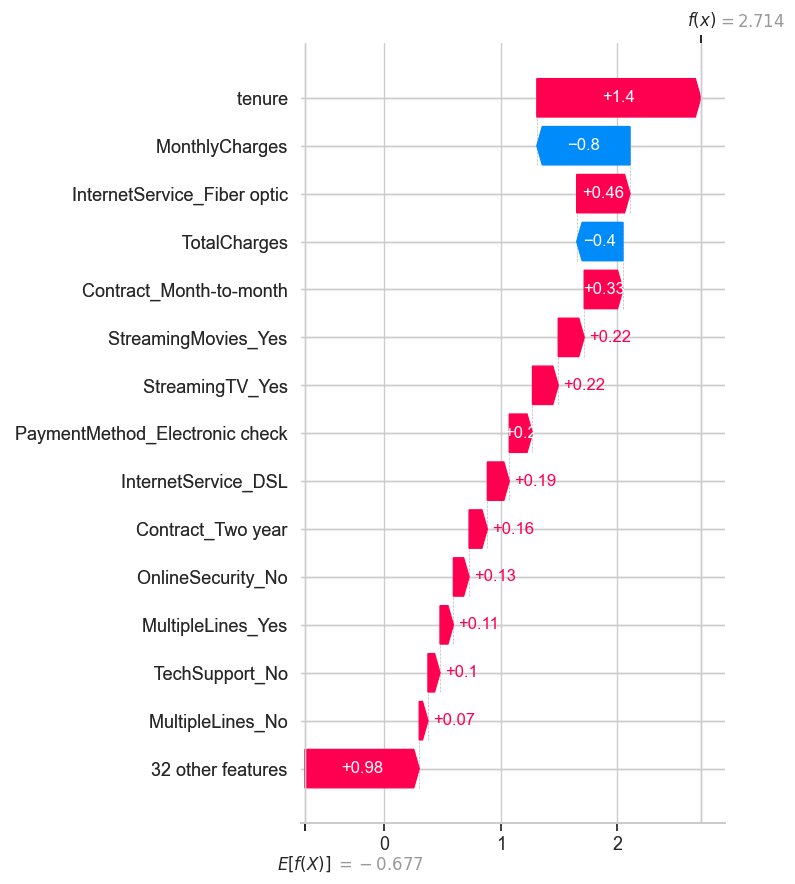

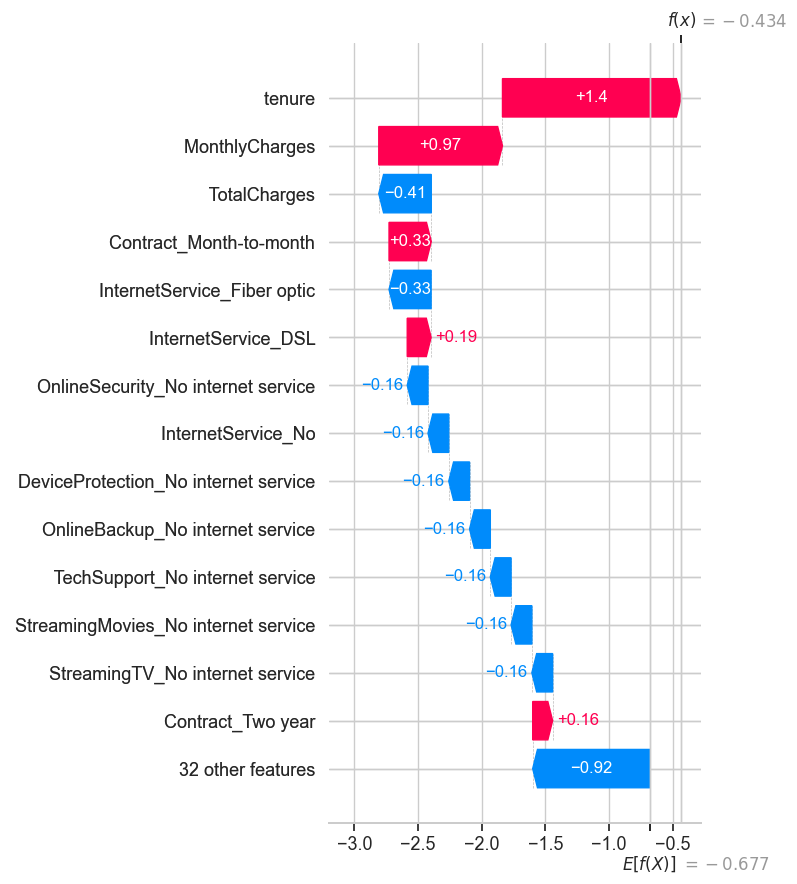

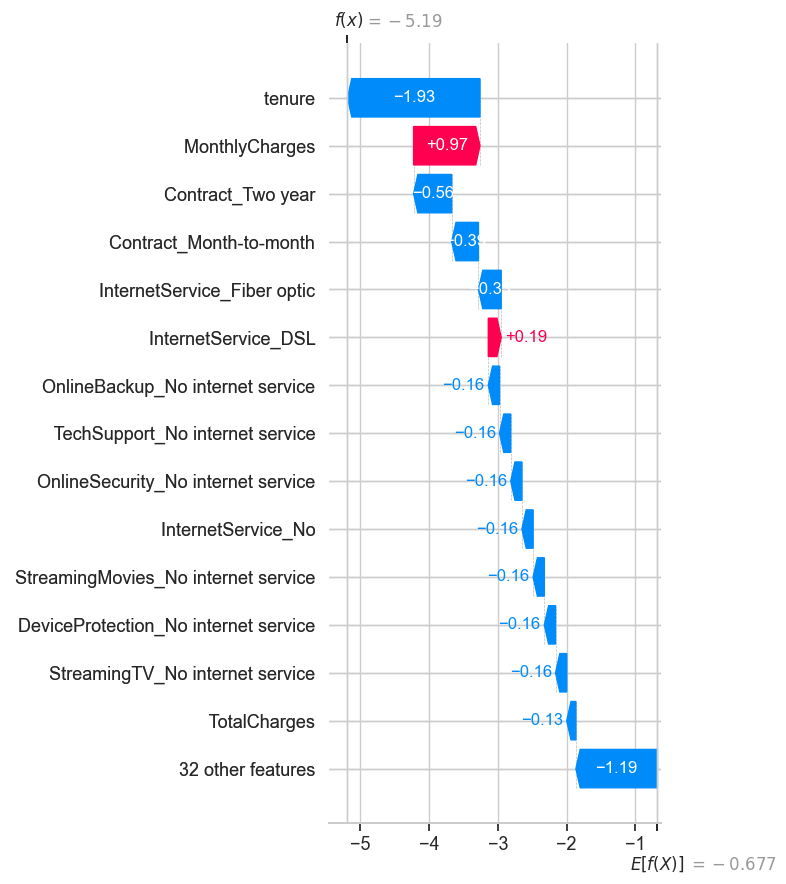

In [19]:
#local waterfall plots 
for i in examples:
    if isinstance(sv_for_plot, list):          
        row_vals = sv_for_plot[1][i]
        base_val = (explainer.expected_value[1]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value)
    else:                                       
        row_vals = sv_for_plot[i]
        base_val = (explainer.expected_value[1]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value)

    row_vals = np.array(row_vals).ravel()
    row_feats = np.array(Xte_trans[i]).ravel()

    shap.plots._waterfall.waterfall_legacy(
        base_val,
        row_vals,
        features = row_feats,
        feature_names = feat_names,
        max_display = 15,
        show = False
    )
    plt.tight_layout()
    plt.savefig(f"images/shap_local_{i}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

C:\Users\пк\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


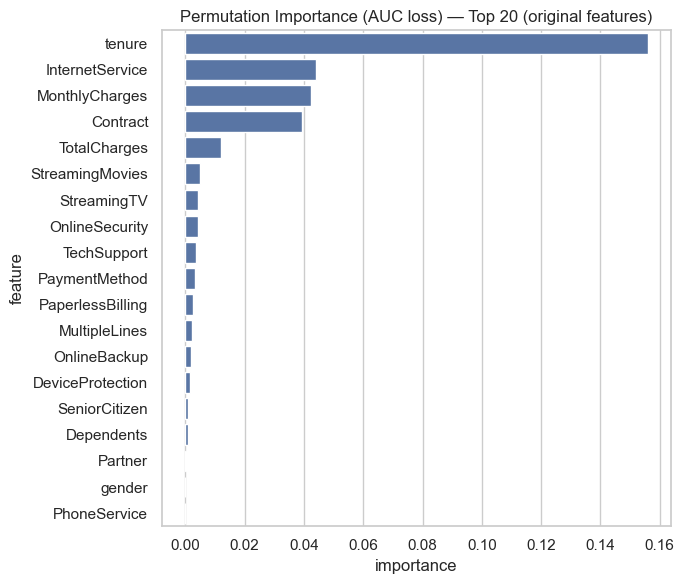

In [23]:
#permutation importance (model-agnostic sanity check)
perm = permutation_importance(
    pipe, X_test, y_test,
    n_repeats = 10, random_state = RANDOM_STATE, n_jobs = -1, scoring = "roc_auc"
)

pi = (pd.DataFrame({
        "feature": X_test.columns,                 
        "importance": perm.importances_mean
      })
      .sort_values("importance", ascending = False)
      .head(20))

plt.figure(figsize = (7, 6))
sns.barplot(data = pi, x = "importance", y = "feature")
plt.title("Permutation Importance (AUC loss) — Top 20 (original features)")
plt.tight_layout(); plt.savefig("images/perm_importance.png", dpi = 300); plt.show()

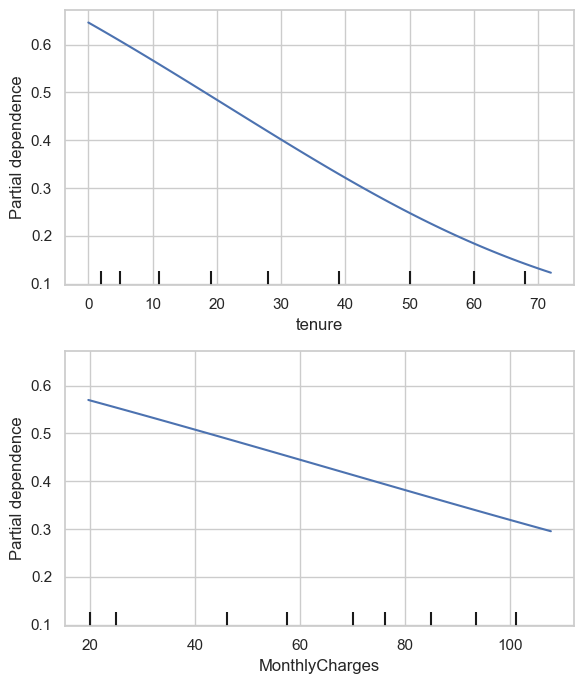

In [25]:
numeric_top = [f for f in top_feats if f in num_cols][:2] or num_cols[:2]
if numeric_top:
    fig, ax = plt.subplots(len(numeric_top), 1, figsize = (6, 3.5*len(numeric_top)))
    PartialDependenceDisplay.from_estimator(pipe, X_test, features = numeric_top, ax = ax)
    plt.tight_layout(); plt.savefig("images/pdp_numeric.png", dpi = 300); plt.show()
else:
    print("No numeric features identified in top features; skipping PDP.")